# Fase 7 — Evaluación Final Comparativa
Grafo de conocimiento sobre investigadores UAM-Azcapotzalco  
Clasificación de 746 artículos en 10 categorías cs.* — transferencia pura, sin ground truth en UAM-A

## Celda 1 — Imports y configuración

In [102]:
# ==============================================================
# Celda 1 — Imports y configuración (ESTRUCTURA DEFINITIVA)
# ==============================================================

import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 120)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted')

# --- RUTA BASE ---
ROOT_PATH = Path(r'C:\Users\Aaron\Documents\arxiv_cs_dataset_exploration\dataset')

# --- 0. DATASET BASE UAM-A ---
UAM_PATH = ROOT_PATH / 'Articulos.csv' 

# --- 1. PREDICCIONES (7 modelos) ---
PRED_PATHS = {
    '1_baseline_noaug': ROOT_PATH / 'predicciones_uam_baseline_sin_aug.csv',
    '2_baseline_aug':   ROOT_PATH / 'predicciones_uam_baseline_con_aug_04_04_2026_17_10_54.csv',
    '3_bilstm_manual':  ROOT_PATH / 'bilstm_manual_predictions_uam.parquet',         # << VERIFICAR NOMBRE REAL
    '4_bilstm_optuna':  ROOT_PATH / 'bilstm_optuna_predictions_uam_02_04_2026_14_08_04.parquet',
    '5_scibert_r1':     ROOT_PATH / 'scibert_predictions_uam_03_04_2026_03_02_07.parquet',
    '6_scibert_r2':     ROOT_PATH / 'scibert_predictions_uam_03_04_2026_11_32_24.parquet', # << VERIFICAR NOMBRE REAL
    '7_zeroshot':       ROOT_PATH / 'zeroshot_predictions_uam_03_04_2026_23_41_04.parquet'
}

# --- 2. MÉTRICAS (7 modelos, opcionales para la comparación) ---
METRICS_PATHS = {
    '1_baseline_noaug': ROOT_PATH / 'baseline_sin_aug_metrics.json',
    '2_baseline_aug':   ROOT_PATH / 'baseline_con_aug_metrics.json',
    '3_bilstm_manual':  ROOT_PATH / 'bilstm_manual_metrics.json',                   # << VERIFICAR NOMBRE REAL
    '4_bilstm_optuna':  ROOT_PATH / 'bilstm_optuna_metrics_02_04_2026_14_08_04.json',
    '5_scibert_r1':     ROOT_PATH / 'scibert_metrics_03_04_2026_03_02_07.json',
    '6_scibert_r2':     ROOT_PATH / 'scibert_metrics_03_04_2026_11_32_24.json',     # << VERIFICAR NOMBRE REAL
    '7_zeroshot':       ROOT_PATH / 'zeroshot_metrics_03_04_2026_23_41_04.json'
}

# --- 3. CONFIGURACIÓN DEL EXPERIMENTO ---
CATEGORIAS = {
    'cs.AI': 'Artificial Intelligence',
    'cs.CL': 'Computation & Language (NLP)',
    'cs.CR': 'Cryptography & Security',
    'cs.CV': 'Computer Vision',
    'cs.DS': 'Data Structures & Algorithms',
    'cs.IT': 'Information Theory',
    'cs.LG': 'Machine Learning',
    'cs.NA': 'Numerical Analysis',
    'cs.RO': 'Robotics',
    'cs.SY': 'Systems & Control',
}
CLASES = list(CATEGORIAS.keys())
RANDOM_SEED = 42

# Archivo de salida final (el maestro que crearemos en la celda 3)
OUTPUT_PATH = 'uam_a_etiquetado_final.parquet'

# Paleta de colores por modelo (ahora para 7 modelos)
COLORES_MODELO = {
    '1_baseline_noaug': '#95A5A6', # Griso (para diferenciarlo del aug)
    '2_baseline_aug':   '#7F8C8D', # Gris
    '3_bilstm_manual':  '#1B4F72', # Azul oscuro
    '4_bilstm_optuna':  '#2E86C1', # Azul claro
    '5_scibert_r1':     '#534AB7', # Morado
    '6_scibert_r2':     '#7D3C98', # Morado claro
    '7_zeroshot':       '#BA7517', # Naranja
}

print('Configuración cargada. Modelos a evaluar:', len(PRED_PATHS))

Configuración cargada. Modelos a evaluar: 7


## Celda 2 — Carga y verificación de archivos de resultados

In [103]:
# ==============================================================
# Celda 2 — Carga y verificación de los 15 archivos (1 base + 14 resultados)
# ==============================================================

# 1. Verificación de existencia
print("--- VERIFICACIÓN DE ARCHIVOS ---")
archivos_todos = {'Dataset UAM': UAM_PATH, **PRED_PATHS, **METRICS_PATHS}
faltantes = []

for nombre, ruta in archivos_todos.items():
    estado = ' OK' if ruta.exists() else '❌ FALTA'
    print(f"{estado:10s} | {nombre:20s} | {ruta.name}")
    if not ruta.exists():
        faltantes.append(nombre)

if faltantes:
    print(f"\n[!] ADVERTENCIA: Faltan {len(faltantes)} archivos. El código fallará si intentas usarlos.")
else:
    print("\n Todos los archivos encontrados en el sistema.")

# 2. Carga del Dataset Base UAM-A
print("\n--- CARGA DE DATOS ---")
df_uam = pd.read_csv(UAM_PATH)
print(f"Dataset UAM-A cargado: {len(df_uam):,} artículos (Columnas: {list(df_uam.columns)})")

# 3. Carga dinámica de Predicciones
dfs_predicciones = {}
print("\nCargando predicciones:")
for nombre, ruta in PRED_PATHS.items():
    if not ruta.exists(): continue
    
    if ruta.suffix == '.csv':
        df_temp = pd.read_csv(ruta)
    elif ruta.suffix == '.parquet':
        df_temp = pd.read_parquet(ruta)
    else:
        continue
        
    # Filtro específico para modelos BiLSTM (solo artículos en inglés)
    if 'bilstm' in nombre and 'idioma' in df_temp.columns:
        len_original = len(df_temp)
        df_temp = df_temp[df_temp['idioma'] == 'en'].reset_index(drop=True)
        print(f"  - {nombre}: {len_original:,} -> {len(df_temp):,} artículos (filtrado a inglés)")
    else:
        print(f"  - {nombre}: {len(df_temp):,} artículos")
        
    dfs_predicciones[nombre] = df_temp

# 4. Carga dinámica de Métricas
dict_metricas = {}
print("\nCargando métricas (JSON):")
for nombre, ruta in METRICS_PATHS.items():
    if not ruta.exists(): continue
    with open(ruta, 'r', encoding='utf-8') as f:
        dict_metricas[nombre] = json.load(f)
    print(f"  - {nombre}: cargado correctamente")


dfs_predicciones.get('5_scibert_r1').drop('pred_scibert_idx', axis=1, inplace=True)

print("\n Fase de carga completada.")

--- VERIFICACIÓN DE ARCHIVOS ---
 OK        | Dataset UAM          | Articulos.csv
 OK        | 1_baseline_noaug     | baseline_sin_aug_metrics.json
 OK        | 2_baseline_aug       | baseline_con_aug_metrics.json
❌ FALTA    | 3_bilstm_manual      | bilstm_manual_metrics.json
 OK        | 4_bilstm_optuna      | bilstm_optuna_metrics_02_04_2026_14_08_04.json
 OK        | 5_scibert_r1         | scibert_metrics_03_04_2026_03_02_07.json
 OK        | 6_scibert_r2         | scibert_metrics_03_04_2026_11_32_24.json
 OK        | 7_zeroshot           | zeroshot_metrics_03_04_2026_23_41_04.json

[!] ADVERTENCIA: Faltan 1 archivos. El código fallará si intentas usarlos.

--- CARGA DE DATOS ---
Dataset UAM-A cargado: 1,112 artículos (Columnas: ['Resumen'])

Cargando predicciones:
  - 1_baseline_noaug: 746 artículos
  - 2_baseline_aug: 746 artículos
  - 4_bilstm_optuna: 1,112 -> 746 artículos (filtrado a inglés)
  - 5_scibert_r1: 746 artículos
  - 7_zeroshot: 746 artículos

Cargando métricas (JSON

## Celda 3 — Consolidación del DataFrame maestro de 746 artículos

In [104]:
# ==============================================================
# Celda 3 — Consolidación del DataFrame Maestro (746 artículos)
# ==============================================================

# Nombres estandarizados que queremos tener en nuestro DataFrame final
NOMBRES_ESTANDAR = {
    '1_baseline_noaug': 'pred_baseline_noaug',
    '2_baseline_aug':   'pred_baseline_aug',
    #'3_bilstm_manual':  'pred_bilstm_manual',
    '4_bilstm_optuna':  'pred_bilstm_optuna',
    '5_scibert_r1':     'pred_scibert_r1',
    #'6_scibert_r2':     'pred_scibert_r2',
    '7_zeroshot':       'pred_zeroshot'
}

# 1. Iniciar el DataFrame maestro solo con los resúmenes originales
df_maestro = df_uam[['Resumen']].copy()

# 2. Bucle para unir cada modelo automáticamente
print("--- UNIENDO PREDICCIONES ---")
for modelo_key, df_modelo in dfs_predicciones.items():
    # Encontrar automáticamente la columna que contiene la predicción
    col_pred_original = [c for c in df_modelo.columns if 'pred' in c.lower()][0]
    
    # Extraer solo el Resumen y la predicción
    temp_df = df_modelo[['Resumen', col_pred_original]].copy()
    
    # Renombrar a nuestro estándar
    nombre_nuevo = NOMBRES_ESTANDAR[modelo_key]
    temp_df.rename(columns={col_pred_original: nombre_nuevo}, inplace=True)
    
    # Merge
    df_maestro = df_maestro.merge(temp_df, on='Resumen', how='left')
    print(f"   Unido: {modelo_key:<20} (Columna original: '{col_pred_original}' -> '{nombre_nuevo}')")

# 3. Limpieza de valores "INVALID" en Zero-shot
# Los convertimos a NaN (nulo) para que no arruinen los conteos, pero no borramos el artículo
invalid_count = df_maestro['pred_zeroshot'].eq('INVALID').sum()
df_maestro['pred_zeroshot'] = df_maestro['pred_zeroshot'].replace('INVALID', np.nan)
if invalid_count > 0:
    print(f"\n  Limpieza: Se convirtieron {invalid_count} valores 'INVALID' de Zero-shot a nulos (NaN).")

# 4. Filtrar para quedarnos estrictamente con los 746 artículos en inglés
# Usamos el baseline_aug como ancla porque en fases anteriores ya tenía exactamente 746 registros
df_maestro = df_maestro.dropna(subset=['pred_baseline_aug']).reset_index(drop=True)
print(f" filtro: DataFrame reducido a {len(df_maestro)} artículos (solo inglés).\n")

# 5. Validación Final de Integridad
print("--- VALIDACIÓN FINAL ---")
columnas_pred = list(NOMBRES_ESTANDAR.values())
nulos_por_col = df_maestro[columnas_pred].isnull().sum()

for col in columnas_pred:
    n_nulos = nulos_por_col[col]
    estado = " Nulos" if n_nulos > 0 else "✅ Lleno"
    print(f"  {estado:10s} | {col:<25} | {n_nulos} nulos")

# Verificar que no queden categorías fuera del catálogo (excepto los NaN que ya limpiamos)
for col in columnas_pred:
    invalidas = df_maestro[df_maestro[col].notna() & ~df_maestro[col].isin(CLASES)][col].unique()
    if len(invalidas) > 0:
        print(f"  ❌ ERROR en {col}: Contiene categorías no válidas -> {invalidas}")

# 6. Guardar el resultado
df_maestro.to_parquet(OUTPUT_PATH, index=False)
print(f"\n Archivo maestro guardado exitosamente en: '{OUTPUT_PATH}'")
print(f"   Dimensiones finales: {df_maestro.shape[0]} filas x {df_maestro.shape[1]} columnas")

# Mostrar una muestra
df_maestro.head(3)

--- UNIENDO PREDICCIONES ---
   Unido: 1_baseline_noaug     (Columna original: 'pred_baseline' -> 'pred_baseline_noaug')
   Unido: 2_baseline_aug       (Columna original: 'pred_baseline' -> 'pred_baseline_aug')
   Unido: 4_bilstm_optuna      (Columna original: 'pred_bilstm' -> 'pred_bilstm_optuna')
   Unido: 5_scibert_r1         (Columna original: 'pred_scibert' -> 'pred_scibert_r1')
   Unido: 7_zeroshot           (Columna original: 'pred_zeroshot' -> 'pred_zeroshot')

  Limpieza: Se convirtieron 113 valores 'INVALID' de Zero-shot a nulos (NaN).
 filtro: DataFrame reducido a 746 artículos (solo inglés).

--- VALIDACIÓN FINAL ---
  ✅ Lleno    | pred_baseline_noaug       | 0 nulos
  ✅ Lleno    | pred_baseline_aug         | 0 nulos
  ✅ Lleno    | pred_bilstm_optuna        | 0 nulos
  ✅ Lleno    | pred_scibert_r1           | 0 nulos
   Nulos     | pred_zeroshot             | 113 nulos

 Archivo maestro guardado exitosamente en: 'uam_a_etiquetado_final.parquet'
   Dimensiones finales: 746 f

,Resumen,pred_baseline_noaug,pred_baseline_aug,pred_bilstm_optuna,pred_scibert_r1,pred_zeroshot
0,Self stabilization effects were experimentally observed in the first period of operation of the ATF device. This eff...,cs.NA,cs.SY,cs.SY,cs.SY,cs.SY
1,The current work on stellarators being carried out in fusion research laboratories around the world is summarized. T...,cs.CL,cs.RO,cs.NA,cs.SY,cs.NA
2,"We prove that a graph is 4-colorable if and only if it can be drawn with vertices in the integer lattice, using as e...",cs.DS,cs.DS,cs.DS,cs.DS,NaN


##  Celda 4 — Análisis Comparativo y Concordancia entre Modelos

In [105]:
# ==============================================================
# Celda 4 — Análisis Comparativo y Concordancia entre Modelos
# ==============================================================
"""
columnas_pred = list(NOMBRES_ESTANDAR.values())
modelos_nombres_cortos = ['Baseline (No Aug)', 'Baseline (Aug)', 'BiLSTM Manual', 
"""
                          
columnas_pred = list(NOMBRES_ESTANDAR.values())
modelos_nombres_cortos = ['Baseline (No Aug)', 'Baseline (Aug)', 
                          'BiLSTM Optuna', 'SciBERT R1', 'Zero-shot']
# -------------------------------------------------------------
# 0. Función auxiliar para extraer el F1 sin importar el formato del JSON
# -------------------------------------------------------------
"""
def extraer_f1_val(m):
    if not m: return np.nan
    # Intenta buscar en la estructura anidada de los Baselines
    f1 = m.get('metricas_val_arxiv', {}).get('macro_f1_val_arxiv')
    if f1 is not None: return float(f1)
    # Intenta buscar en la estructura plana de BiLSTM / SciBERT
    f1 = m.get('macro_f1_arxiv_val') or m.get('macro_f1_val_arxiv')
    if f1 is not None: return float(f1)
    return np.nan

def extraer_precision_val(m):
    if not m: return np.nan
    return float(m.get('metricas_val_arxiv', {}).get('macro_precision_val_arxiv', np.nan))

def extraer_recall_val(m):
    if not m: return np.nan
    return float(m.get('metricas_val_arxiv', {}).get('macro_recall_val_arxiv', np.nan))

# -------------------------------------------------------------
# 1. Tabla Comparativa de Métricas (desde los archivos JSON)
# -------------------------------------------------------------
print("--- 1. RENDIMIENTO EN CONJUNTO DE VALIDACIÓN (Con Ground Truth) ---\n")
lista_metricas = []

for key, nombre_bonito in zip(dict_metricas.keys(), modelos_nombres_cortos):
    m = dict_metricas.get(key, {})
    lista_metricas.append({
        'Modelo': nombre_bonito,
        'Macro F1 (Val)': extraer_f1_val(m),
        'Macro Precision (Val)': extraer_precision_val(m),
        'Macro Recall (Val)': extraer_recall_val(m),
        'Hallazgo Principal': m.get('hallazgo_principal') or m.get('confusion_pattern', '-')
    })

df_metricas_val = pd.DataFrame(lista_metricas).set_index('Modelo')
# Formatear y mostrar (las celdas NaN de Precision/Recall aparecerán vacías, lo cual es correcto)
display(df_metricas_val.style.format("{:.4f}", subset=['Macro F1 (Val)', 'Macro Precision (Val)', 'Macro Recall (Val)'])
                     .background_gradient(cmap='Greens', subset=['Macro F1 (Val)'], axis=0))
"""
# -------------------------------------------------------------
# 2. Distribución de Predicciones sobre la UAM (746 artículos)
# -------------------------------------------------------------
print("\n--- 2. DISTRIBUCIÓN DE CLASES EN UAM-A (Sin Ground Truth) ---\n")

df_dist = pd.DataFrame()
for col, nombre_bonito in zip(columnas_pred, modelos_nombres_cortos):
    # value_counts() ignora los NaN (los 113 de zeroshot) automáticamente
    conteo = df_maestro[col].value_counts().reindex(CLASES, fill_value=0)
    df_dist[nombre_bonito] = conteo  # Aquí se guardan con el nombre_bonito

# NUEVO: Insertar la columna 'Descripción' mapeando desde el diccionario CATEGORIAS
df_dist.insert(0, 'Descripción', df_dist.index.map(CATEGORIAS))

# CORREGIDO: Sumar usando 'modelos_nombres_cortos' que son los nombres reales de las columnas
df_dist['Total'] = df_dist[modelos_nombres_cortos].sum(axis=1)

# Mostrar la tabla (Categorías como filas, modelos como columnas)
# Formateamos sin decimales porque son conteos enteros
display(df_dist.style.format("{:.0f}", subset=modelos_nombres_cortos + ['Total']))

# -------------------------------------------------------------
# 3. Análisis de Concordancia (Votación por Mayoría)
# -------------------------------------------------------------
print("\n--- 3. CONCORDANCIA ENTRE MODELOS (Votación por Mayoría) ---")

def calcular_consenso(row):
    """Cuenta los votos de los modelos ignorando NaN (como los de Zero-shot)"""
    votos_validos = row.dropna().tolist()
    if not votos_validos:
        return np.nan, 0, 0
    
    conteo = pd.Series(votos_validos).value_counts()
    etiqueta_ganadora = conteo.index[0]
    votos_ganadora = conteo.iloc[0]
    total_votos = len(votos_validos)
    
    return etiqueta_ganadora, votos_ganadora, total_votos

# Aplicar la función a cada fila (artículo)
resultados_consenso = df_maestro[columnas_pred].apply(calcular_consenso, axis=1, result_type='expand')
resultados_consenso.columns = ['etiqueta_consenso', 'votos_acuerdo', 'total_votos_validos']

# Unir al DataFrame maestro
df_maestro = pd.concat([df_maestro, resultados_consenso], axis=1)

# Porcentaje de acuerdo
df_maestro['pct_acuerdo'] = (df_maestro['votos_acuerdo'] / df_maestro['total_votos_validos']) * 100

# Resumen de la concordancia
print("\nResumen de niveles de acuerdo para los 746 artículos:")
bins = [0, 50, 70, 85, 100]
labels = ['< 50% (Alta discordancia)', '50% - 70% (Moderada)', '70% - 85% (Buena)', '85% - 100% (Casi unánime)']
df_maestro['nivel_consenso'] = pd.cut(df_maestro['pct_acuerdo'], bins=bins, labels=labels, include_lowest=True)

print(df_maestro['nivel_consenso'].value_counts().reindex(labels))

print(f"\n Etiquetas de consenso generadas: {df_maestro['etiqueta_consenso'].nunique()} categorías distintas.")
print(f" Promedio general de acuerdo entre modelos: {df_maestro['pct_acuerdo'].mean():.2f}%")

# Actualizar el archivo parquet con esta nueva información valiosa
df_maestro.to_parquet(OUTPUT_PATH, index=False)
print(f"\n DataFrame maestro actualizado y guardado en '{OUTPUT_PATH}'")


--- 2. DISTRIBUCIÓN DE CLASES EN UAM-A (Sin Ground Truth) ---



,Descripción,Baseline (No Aug),Baseline (Aug),BiLSTM Optuna,SciBERT R1,Zero-shot,Total
pred_baseline_noaug,,,,,,,
cs.AI,Artificial Intelligence,280,265,230,216,118,1109
cs.CL,Computation & Language (NLP),61,57,64,16,47,245
cs.CR,Cryptography & Security,25,32,32,22,7,118
cs.CV,Computer Vision,32,32,39,8,38,149
cs.DS,Data Structures & Algorithms,58,57,49,103,92,359
cs.IT,Information Theory,14,14,16,5,9,58
cs.LG,Machine Learning,22,21,29,0,58,130
cs.NA,Numerical Analysis,141,146,165,185,148,785
cs.RO,Robotics,8,10,9,18,6,51



--- 3. CONCORDANCIA ENTRE MODELOS (Votación por Mayoría) ---

Resumen de niveles de acuerdo para los 746 artículos:
nivel_consenso
< 50% (Alta discordancia)     83
50% - 70% (Moderada)         141
70% - 85% (Buena)            218
85% - 100% (Casi unánime)    304
Name: count, dtype: int64

 Etiquetas de consenso generadas: 10 categorías distintas.
 Promedio general de acuerdo entre modelos: 79.92%

 DataFrame maestro actualizado y guardado en 'uam_a_etiquetado_final.parquet'


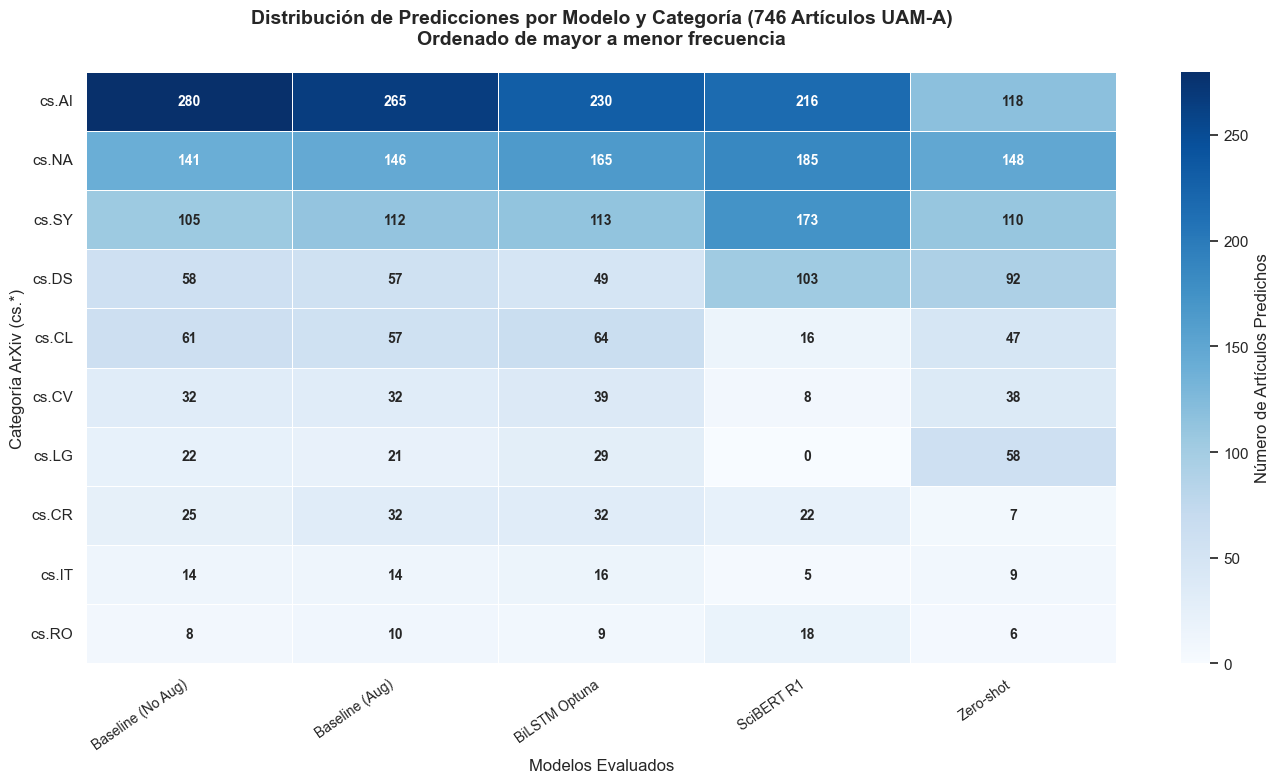

In [129]:
# ==============================================================
# Celda 5 — Visualización: Heatmap de Distribución (Ordenado y Azul)
# ==============================================================

modelos_nombres_cortos = ['Baseline (No Aug)', 'Baseline (Aug)', 
                          'BiLSTM Optuna', 'SciBERT R1', 'Zero-shot']

# 1. Preparar los datos excluyendo 'Descripción' y 'Total'
df_heatmap = df_dist[modelos_nombres_cortos].copy()

# NUEVO: Ordenar las filas (categorías) de mayor a menor según la columna 'Total'
df_heatmap_sorted = df_heatmap.loc[df_dist['Total'].sort_values(ascending=False).index]

plt.figure(figsize=(14, 8))

# 2. Crear el Heatmap
ax = sns.heatmap(
    df_heatmap_sorted, 
    annot=True,            
    fmt="d",               
    cmap="Blues",           # Paleta de Azul fuerte a Blanco
    linewidths=.5,         
    linecolor='white',
    cbar_kws={'label': 'Número de Artículos Predichos'},
    annot_kws={"size": 10, "fontweight": "bold"} # Negritas para que se lea mejor
)

# 3. Estética de los ejes
#ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=11)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=10)

# 4. Títulos y etiquetas
plt.title('Distribución de Predicciones por Modelo y Categoría (746 Artículos UAM-A)\nOrdenado de mayor a menor frecuencia', 
          fontsize=14, fontweight='bold', pad=20)
plt.ylabel('Categoría ArXiv (cs.*)', fontsize=12)
plt.xlabel('Modelos Evaluados', fontsize=12)

# Ajustar márgenes
plt.tight_layout()

# Mostrar gráfico
plt.show()


--- 1. CONCORDANCIA ENTRE PARES DE MODELOS ---

¿Qué tanto se parecen los modelos entre sí al clasificar los 746 artículos?



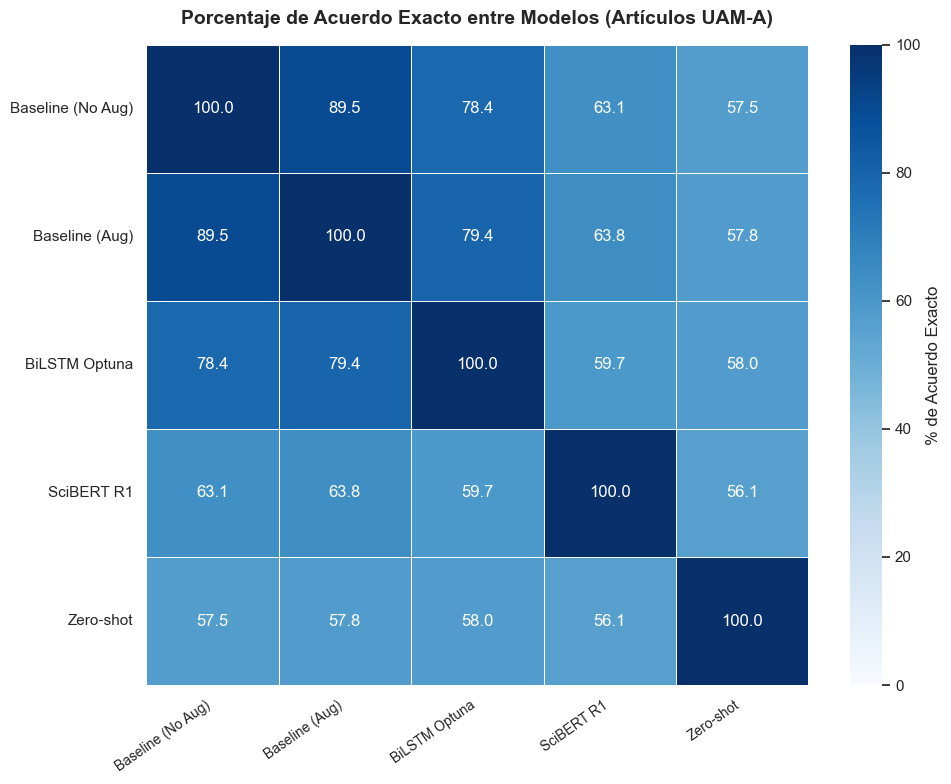


--- 2. ANÁLISIS DE ALTA DISCORDANCIA (< 50% de acuerdo) ---

Se encontraron 53 artículos donde los modelos no se ponen de acuerdo.

Mostrando 3 ejemplos representativos (para tu informe):

* ARTÍCULO #1
Resumen: The current work on stellarators being carried out in fusion research laboratories around the world is summarized. The theoretical aspects of the stellarator research are emphasized....
Predicciones por modelo:
  - Baseline (No Aug)    : cs.CL
  - Baseline (Aug)       : cs.RO
  - BiLSTM Optuna        : cs.NA
  - SciBERT R1           : cs.SY
  - Zero-shot            : cs.NA
  >> CONSENSO: cs.NA (40% de acuerdo)
--------------------------------------------------------------------------------
* ARTÍCULO #15
Resumen: Inventory data of Mexico City's street trees were studied using classical statistical arboricultural and ecological statistical approaches. Multivariate techniques were applied to both. Results did no...
Predicciones por modelo:
  - Baseline (No Aug)    : cs.LG
  - Ba

In [107]:
# ==============================================================
# Celda 6 — Análisis de Patrones y Discordancia (Cierre Comparativo)
# ==============================================================

# -------------------------------------------------------------
# 1. Matriz de Concordancia entre Pares de Modelos (% de Acuerdo)
# -------------------------------------------------------------
print("--- 1. CONCORDANCIA ENTRE PARES DE MODELOS ---\n")
print("¿Qué tanto se parecen los modelos entre sí al clasificar los 746 artículos?\n")

cols_pred = list(NOMBRES_ESTANDAR.values())
agree_matrix = pd.DataFrame(index=modelos_nombres_cortos, columns=modelos_nombres_cortos, dtype=float)

for i, c1 in enumerate(cols_pred):
    for j, c2 in enumerate(cols_pred):
        # Comparar solo donde ambos modelos tienen predicción válida (ignora NaN de zeroshot)
        valid_idx = df_maestro[[c1, c2]].dropna().index
        if len(valid_idx) > 0:
            acuerdo = (df_maestro.loc[valid_idx, c1] == df_maestro.loc[valid_idx, c2]).sum()
            agree_matrix.iloc[i, j] = (acuerdo / len(valid_idx)) * 100

plt.figure(figsize=(10, 8))
# Paleta de azul a blanco (Blues)
ax = sns.heatmap(agree_matrix.astype(float), annot=True, fmt=".1f", cmap="Blues", 
                 linewidths=.5, linecolor='white',
                 cbar_kws={'label': '% de Acuerdo Exacto'},
                 vmin=0, vmax=100) # Forzar escala 0-100

ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=10)
plt.title('Porcentaje de Acuerdo Exacto entre Modelos (Artículos UAM-A)', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# -------------------------------------------------------------
# 2. Zoom a la "Alta Discordancia" (Ejemplos reales)
# -------------------------------------------------------------
print("\n--- 2. ANÁLISIS DE ALTA DISCORDANCIA (< 50% de acuerdo) ---\n")
df_discordante = df_maestro[df_maestro['pct_acuerdo'] < 50].copy()

if len(df_discordante) > 0:
    print(f"Se encontraron {len(df_discordante)} artículos donde los modelos no se ponen de acuerdo.\n")
    print("Mostrando 3 ejemplos representativos (para tu informe):\n")
    
    for idx, row in df_discordante.head(3).iterrows():
        print(f"* ARTÍCULO #{idx}")
        print(f"Resumen: {str(row['Resumen'])[:200]}...")
        print("Predicciones por modelo:")
        for col, nombre in zip(cols_pred, modelos_nombres_cortos):
            pred = row[col]
            if pd.notna(pred):
                print(f"  - {nombre:<20} : {pred}")
        print(f"  >> CONSENSO: {row['etiqueta_consenso']} ({row['pct_acuerdo']:.0f}% de acuerdo)")
        print("-" * 80)
else:
    print("No hay artículos con alta discordancia. Todos los modelos concuerdan bastante.")

# -------------------------------------------------------------
# 3. Cuantificación del patrón cs.AI vs cs.LG
# -------------------------------------------------------------
print("\n--- 3. ANÁLISIS DEL PATRÓN cs.AI vs cs.LG ---\n")
print("Hallazgo principal de fases anteriores: Los modelos lineales confunden ML con AI.\n")

# Comparamos el peor caso de sesgo (Baseline No Aug) contra el mejor modelo (SciBERT R2)
conflicto_ai_lg = df_maestro[
    (df_maestro['pred_baseline_noaug'] == 'cs.AI') & 
    (df_maestro['pred_scibert_r1'] == 'cs.LG')
]
conflicto_lg_ai = df_maestro[
    (df_maestro['pred_baseline_noaug'] == 'cs.LG') & 
    (df_maestro['pred_scibert_r1'] == 'cs.AI')
]

print(f"Comparando Baseline (No Aug) vs SciBERT (Run 2):")
print(f"  - Artículos que Baseline clasifica como 'cs.AI' pero SciBERT como 'cs.LG': {len(conflicto_ai_lg)}")
print(f"  - Artículos que Baseline clasifica como 'cs.LG' pero SciBERT como 'cs.AI': {len(conflicto_lg_ai)}")
print(f"\n>> Conclusión: Esto confirma que el {((len(conflicto_ai_lg)+len(conflicto_lg_ai))/746)*100:.1f}% de las discrepancias "
      f"entre modelos tradicionales y de Deep Learning se centra en la frontera teórica entre "
      f"Inteligencia Artificial general y Aprendizaje Automático (Machine Learning) específico.")